In [1]:
# === Cell 1: Import libraries and load data ===
# Rationale: This notebook builds on notebook 01. We reload the data
# and apply the same cleaning steps so this notebook is self-contained
# (anyone can run it independently without running notebook 01 first).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load tables
metadata = pd.read_csv('../data/metadata.csv', sep=';')
asv_table = pd.read_excel('../data/seqtab_nochim_export.xlsx')
asv_table = asv_table.rename(columns={'Unnamed: 0': 'SampleID'}).set_index('SampleID')

print(f"Metadata: {metadata.shape[0]} samples")
print(f"ASV table: {asv_table.shape[0]} samples x {asv_table.shape[1]} ASVs")
print(f"\nDisease groups:")
print(metadata['DiseaseStatus'].value_counts())

Metadata: 59 samples
ASV table: 59 samples x 6693 ASVs

Disease groups:
DiseaseStatus
Colorectal cancer     21
Healthy               19
Adenomatous Polyps    19
Name: count, dtype: int64


In [2]:
# === Cell 2: Calculate alpha diversity metrics ===
# Rationale: We compute 4 standard metrics that capture different aspects
# of within-sample diversity. Each tells a different part of the story:
# - Observed Species: richness (how many types)
# - Shannon: richness + evenness (how balanced)
# - Simpson: dominance-weighted diversity
# - Chao1: estimated true richness (accounts for undetected species)

from skbio.diversity import alpha_diversity

# Observed Species: count of ASVs with abundance > 0
observed = alpha_diversity('observed_otus', asv_table.values, ids=asv_table.index)

# Shannon entropy
shannon = alpha_diversity('shannon', asv_table.values, ids=asv_table.index)

# Simpson (1 - D): probability two random individuals are different species
simpson = alpha_diversity('simpson', asv_table.values, ids=asv_table.index)

# Chao1: estimated true richness
chao1 = alpha_diversity('chao1', asv_table.values, ids=asv_table.index)

# Combine into a single DataFrame
alpha_df = pd.DataFrame({
    'host_disease': asv_table.index,
    'Observed_Species': observed.values,
    'Shannon': shannon.values,
    'Simpson': simpson.values,
    'Chao1': chao1.values
})

# Merge with disease status
alpha_df = alpha_df.merge(metadata[['host_disease', 'DiseaseStatus']], on='host_disease')

print("=== ALPHA DIVERSITY SUMMARY ===")
display(alpha_df.groupby('DiseaseStatus')[['Observed_Species', 'Shannon', 'Simpson', 'Chao1']].describe().round(2))

=== ALPHA DIVERSITY SUMMARY ===


c:\Users\Oscar\anaconda3\envs\bioinfo\Lib\site-packages\skbio\util\_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


Observed_Species                                       \
                              count    mean     std    min    25%    50%   
DiseaseStatus                                                              
Adenomatous Polyps             19.0  328.84  112.59  149.0  259.5  313.0   
Colorectal cancer              21.0  407.86  101.95  232.0  312.0  454.0   
Healthy                        19.0  371.16   93.49  159.0  308.0  380.0   

                                 Shannon        ... Simpson      Chao1  \
                      75%    max   count  mean  ...     75%  max count   
DiseaseStatus                                   ...                      
Adenomatous Polyps  403.0  525.0    19.0  5.32  ...     1.0  1.0  19.0   
Colorectal cancer   474.0  597.0    21.0  5.64  ...     1.0  1.0  21.0   
Healthy             425.0  513.0    19.0  5.51  ...     1.0  1.0  19.0   

                                                                           
                      mean     std     min    25%     50%     75%     max  
DiseaseStatus                                                              
Adenomatous Polyps  329.05  112.74  149.17  259.5  313.00  403.30  526.62  
Colorectal cancer   408.20  102.13  232.00  312.0  455.07  474.56  597.00  
Healthy             371.40   93.61  159.00  308.1  380.00  425.61  513.38  

[3 rows x 32 columns]

In [3]:
# === Cell 3: Clean summary of alpha diversity by group ===
# Rationale: The full describe() table is too wide. We show just mean ± std
# per group, which is the standard way to report alpha diversity in papers.

summary = alpha_df.groupby('DiseaseStatus')[['Observed_Species', 'Shannon', 'Simpson', 'Chao1']].agg(['mean', 'std']).round(2)
display(summary)

print("\n=== KEY OBSERVATIONS ===")
print("Observed Species (mean):")
for group in ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']:
    mean = alpha_df[alpha_df['DiseaseStatus'] == group]['Observed_Species'].mean()
    print(f"  {group}: {mean:.0f}")

Observed_Species         Shannon       Simpson       \
                               mean     std    mean   std    mean  std   
DiseaseStatus                                                            
Adenomatous Polyps           328.84  112.59    5.32  0.48    0.99  0.0   
Colorectal cancer            407.86  101.95    5.64  0.32    1.00  0.0   
Healthy                      371.16   93.49    5.51  0.30    0.99  0.0   

                     Chao1          
                      mean     std  
DiseaseStatus                       
Adenomatous Polyps  329.05  112.74  
Colorectal cancer   408.20  102.13  
Healthy             371.40   93.61


=== KEY OBSERVATIONS ===
Observed Species (mean):
  Healthy: 371
  Adenomatous Polyps: 329
  Colorectal cancer: 408


C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\1166837193.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\1166837193.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\1166837193.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\1166837193.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklab

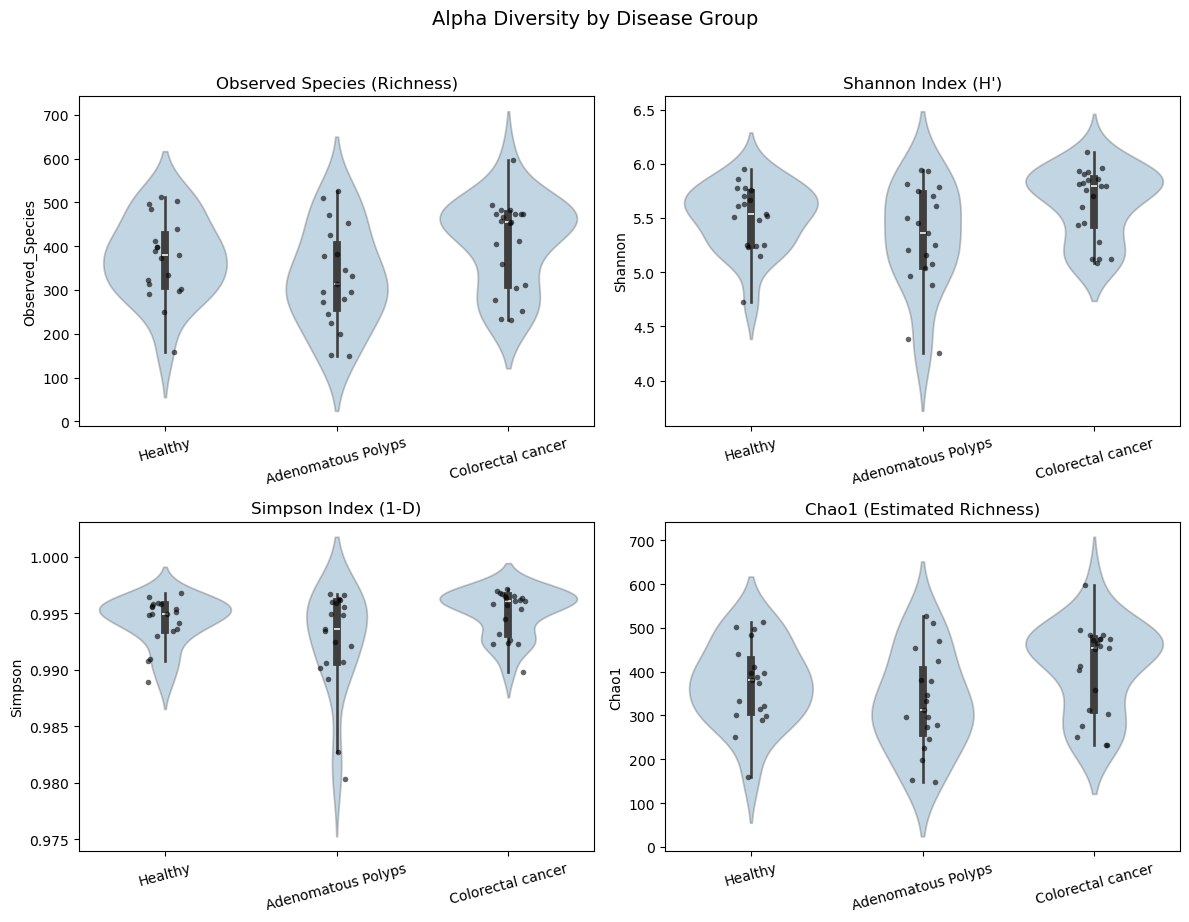

In [4]:
# === Cell 4: Violin + strip plots for all alpha diversity metrics ===
# Rationale: We plot all 4 metrics side by side to compare groups visually.
# Using subplots (2x2 grid) keeps everything compact and comparable.
# Violin shows distribution shape, strip shows individual data points.
# We order groups as Healthy → Polyps → CRC to reflect disease progression.

group_order = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']
metrics = ['Observed_Species', 'Shannon', 'Simpson', 'Chao1']
titles = ['Observed Species (Richness)', 'Shannon Index (H\')', 
          'Simpson Index (1-D)', 'Chao1 (Estimated Richness)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.violinplot(data=alpha_df, x='DiseaseStatus', y=metric,
                   order=group_order, alpha=0.3, ax=axes[i])
    sns.stripplot(data=alpha_df, x='DiseaseStatus', y=metric,
                  order=group_order, color='black', size=4, alpha=0.6, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)

fig.suptitle('Alpha Diversity by Disease Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

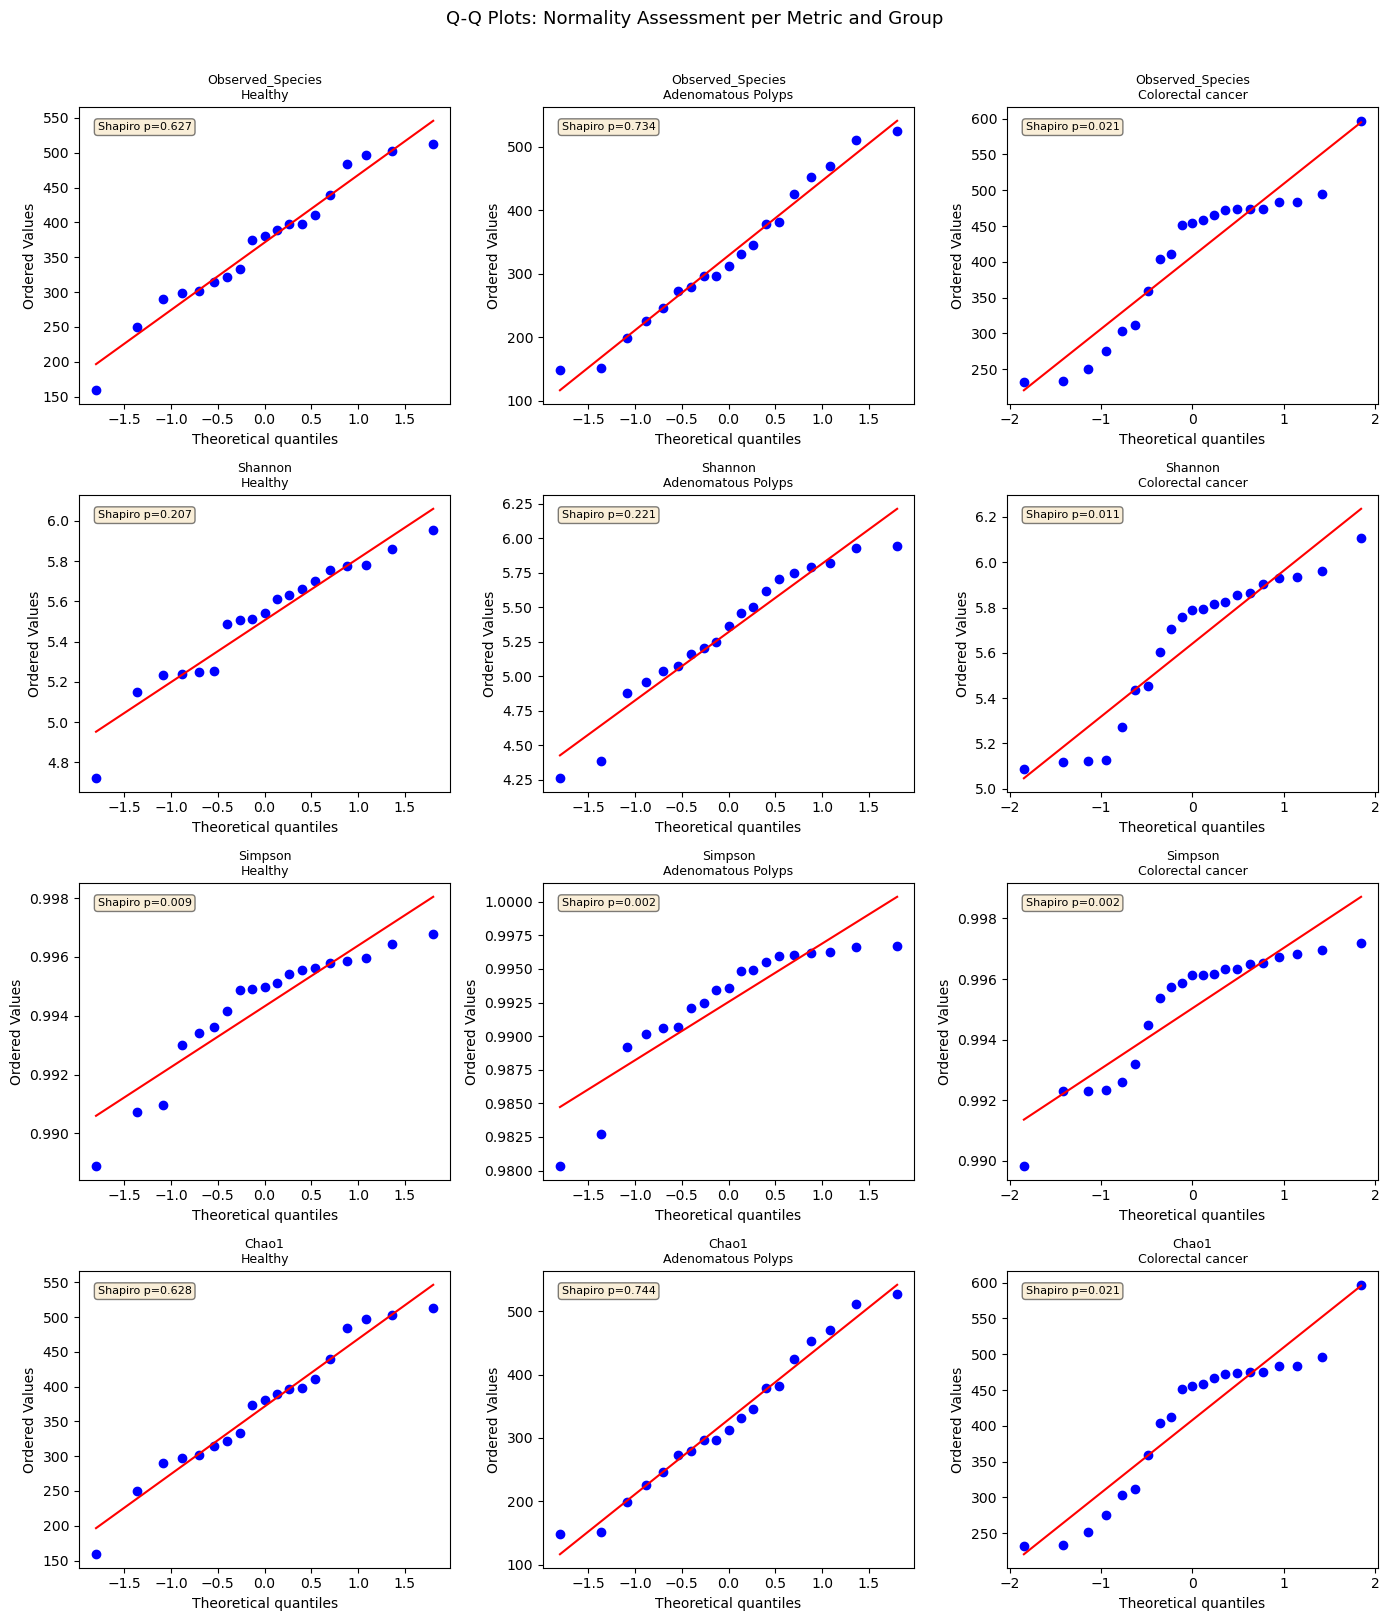

In [5]:
# === Cell 5: Normality assessment for alpha diversity metrics ===
# Rationale: Before choosing a statistical test, we must check if our data
# follows a normal distribution. If it does → ANOVA is valid. If not →
# we need non-parametric tests (Kruskal-Wallis).
# We use two approaches:
# 1. Visual: histograms + Q-Q plots (if data is normal, points follow the diagonal)
# 2. Statistical: Shapiro-Wilk test (the standard normality test for small samples)
#    - p > 0.05 → we cannot reject normality (data could be normal)
#    - p < 0.05 → data significantly deviates from normal distribution

from scipy.stats import shapiro, probplot

metrics = ['Observed_Species', 'Shannon', 'Simpson', 'Chao1']
groups = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']

# Visual assessment: Q-Q plots per metric per group
fig, axes = plt.subplots(4, 3, figsize=(14, 16))

for i, metric in enumerate(metrics):
    for j, group in enumerate(groups):
        data = alpha_df[alpha_df['DiseaseStatus'] == group][metric].values
        probplot(data, dist="norm", plot=axes[i][j])
        axes[i][j].set_title(f'{metric}\n{group}', fontsize=9)
        
        # Add Shapiro-Wilk p-value to the plot
        stat, p = shapiro(data)
        axes[i][j].text(0.05, 0.95, f'Shapiro p={p:.3f}', 
                        transform=axes[i][j].transAxes, fontsize=8,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Q-Q Plots: Normality Assessment per Metric and Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Normality Assessment — Conclusion

Shapiro-Wilk tests show that the Colorectal cancer group violates normality (p < 0.05) in Observed Species, Shannon, and Chao1. Simpson violates normality in all three groups. Since ANOVA requires normality in all groups, we proceed with non-parametric tests: **Kruskal-Wallis** for 3-group comparison and **Mann-Whitney U** for pairwise tests.

In [6]:
# === Cell 7: Statistical tests for alpha diversity differences ===
# Rationale: Kruskal-Wallis tests if there's ANY difference between the 3 groups.
# If significant, Mann-Whitney U identifies WHICH specific pairs differ.
# Bonferroni correction adjusts p-values for multiple comparisons —
# with 3 pairs, we multiply each p-value by 3 to reduce false positives.

from scipy.stats import kruskal, mannwhitneyu

metrics = ['Observed_Species', 'Shannon', 'Simpson', 'Chao1']
groups = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']

print("=== KRUSKAL-WALLIS TEST (3-group comparison) ===\n")
for metric in metrics:
    group_data = [alpha_df[alpha_df['DiseaseStatus'] == g][metric].values for g in groups]
    stat, p = kruskal(*group_data)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{metric:20s}  H={stat:.2f}  p={p:.4f}  {sig}")

print("\n=== PAIRWISE MANN-WHITNEY U TESTS (Bonferroni corrected) ===\n")
pairs = [('Healthy', 'Colorectal cancer'), 
         ('Healthy', 'Adenomatous Polyps'), 
         ('Adenomatous Polyps', 'Colorectal cancer')]
n_comparisons = len(pairs)

for metric in metrics:
    print(f"--- {metric} ---")
    for g1, g2 in pairs:
        d1 = alpha_df[alpha_df['DiseaseStatus'] == g1][metric].values
        d2 = alpha_df[alpha_df['DiseaseStatus'] == g2][metric].values
        stat, p = mannwhitneyu(d1, d2, alternative='two-sided')
        p_corrected = min(p * n_comparisons, 1.0)
        sig = "***" if p_corrected < 0.001 else "**" if p_corrected < 0.01 else "*" if p_corrected < 0.05 else "ns"
        print(f"  {g1} vs {g2}: U={stat:.0f}  p_corrected={p_corrected:.4f}  {sig}")
    print()

=== KRUSKAL-WALLIS TEST (3-group comparison) ===

Observed_Species      H=4.97  p=0.0832  ns
Shannon               H=6.04  p=0.0487  *
Simpson               H=5.32  p=0.0700  ns
Chao1                 H=4.99  p=0.0825  ns

=== PAIRWISE MANN-WHITNEY U TESTS (Bonferroni corrected) ===

--- Observed_Species ---
  Healthy vs Colorectal cancer: U=164  p_corrected=1.0000  ns
  Healthy vs Adenomatous Polyps: U=228  p_corrected=0.5100  ns
  Adenomatous Polyps vs Colorectal cancer: U=121  p_corrected=0.1038  ns

--- Shannon ---
  Healthy vs Colorectal cancer: U=143  p_corrected=0.3880  ns
  Healthy vs Adenomatous Polyps: U=221  p_corrected=0.7287  ns
  Adenomatous Polyps vs Colorectal cancer: U=115  p_corrected=0.0687  ns

--- Simpson ---
  Healthy vs Colorectal cancer: U=138  p_corrected=0.2955  ns
  Healthy vs Adenomatous Polyps: U=209  p_corrected=1.0000  ns
  Adenomatous Polyps vs Colorectal cancer: U=122  p_corrected=0.1111  ns

--- Chao1 ---
  Healthy vs Colorectal cancer: U=163  p_correct

### Statistical Testing — Results

Kruskal-Wallis tests revealed no significant differences between groups for Observed Species (p=0.083), Simpson (p=0.070), or Chao1 (p=0.083). Shannon index reached marginal significance (p=0.049), but no pairwise comparison survived Bonferroni correction.

**Interpretation:** Alpha diversity alone does not significantly discriminate between Healthy, Adenomatous Polyps, and Colorectal cancer groups in this cohort. This suggests that the key differences lie in **microbiome composition** (which taxa are present) rather than overall diversity — consistent with recent CRC literature. This will inform our feature selection strategy in the ML classification phase.

C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\2719652329.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\2719652329.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\2719652329.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_5408\2719652329.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklab

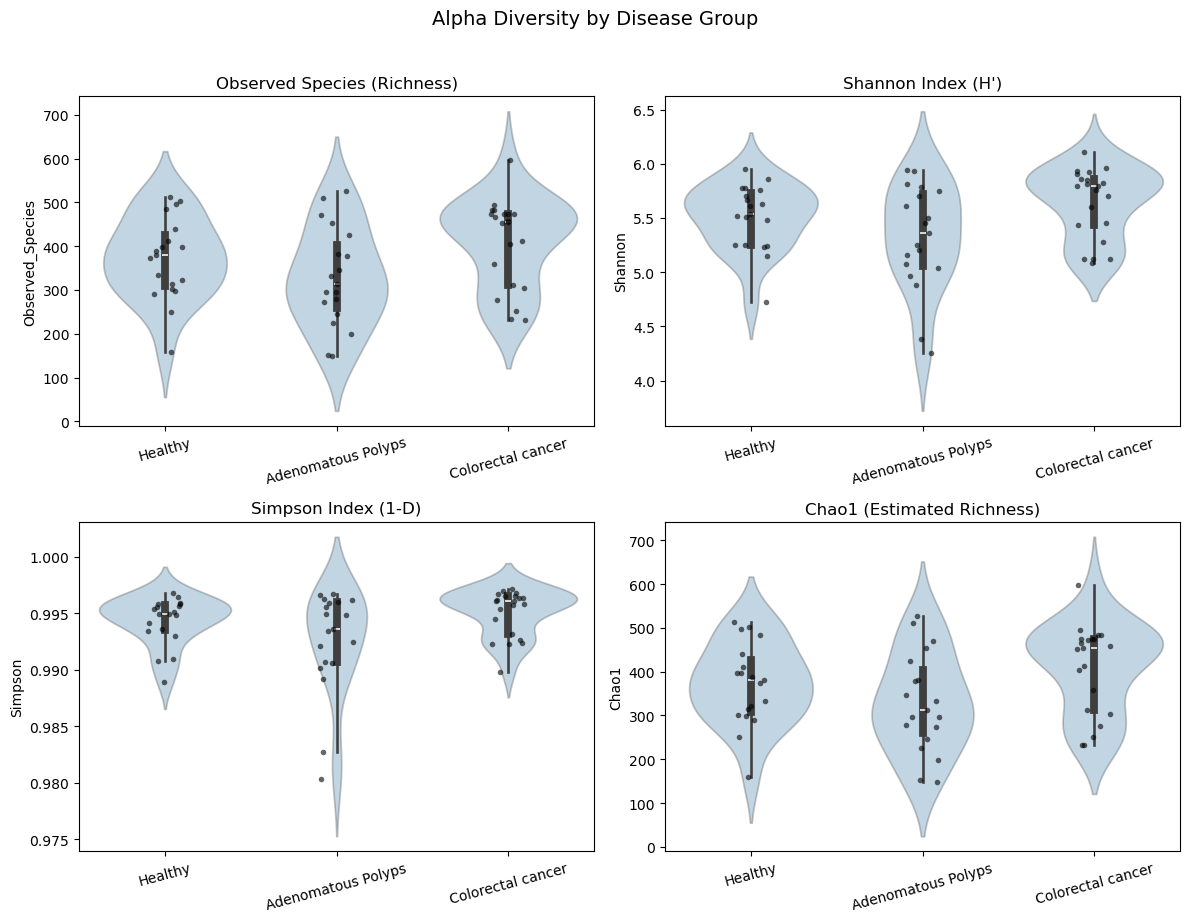

Saved: figures/alpha_diversity_violin.png


In [7]:
# === Cell 8: Save alpha diversity figure ===
# Rationale: Save the 2x2 violin plot for the README and portfolio.

group_order = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']
metrics = ['Observed_Species', 'Shannon', 'Simpson', 'Chao1']
titles = ['Observed Species (Richness)', 'Shannon Index (H\')', 
          'Simpson Index (1-D)', 'Chao1 (Estimated Richness)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.violinplot(data=alpha_df, x='DiseaseStatus', y=metric,
                   order=group_order, alpha=0.3, ax=axes[i])
    sns.stripplot(data=alpha_df, x='DiseaseStatus', y=metric,
                  order=group_order, color='black', size=4, alpha=0.6, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)

fig.suptitle('Alpha Diversity by Disease Group', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('../figures/alpha_diversity_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/alpha_diversity_violin.png")